# 1. Import Libraries

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# 2. Connecting to Database and Converting tables into DataFrame

In [2]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        select name
        from sqlite_master
        where type = 'table'
"""
tables = pd.read_sql(sql_query, conn)

# create dataFrame for each table 
for table_name in tables["name"]:
    df = pd.read_sql(f"select * from {table_name}", conn)
    globals()[f'df_{table_name}'] = df
    print(f"Created DataFrame df_{table_name}")

conn.close()

Created DataFrame df_db_customer
Created DataFrame df_db_subscription
Created DataFrame df_db_support


## Fetching Columns of each three DataFrame

In [3]:
conn = sqlite3.connect("customer_churn.db")

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    #get column info
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print(f"Columns: ")
    print(columns['name'].tolist())

conn.close()


Table Name: db_customer
Columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# 3. Data Cleaning

In [4]:
df_db_customer.head(4)

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None


In [5]:
df_db_customer.info()

"""Conclusion: Total Rows is 21 but country has 3 missing values, interests has only 4 values and pincode has no values. Also dob should be Datetime dtype."""

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


'Conclusion: Total Rows is 21 but country has 3 missing values, interests has only 4 values and pincode has no values. Also dob should be Datetime dtype.'

In [6]:
# a. rename col name to customer_name
# b. drop col interests and pincode
# c. change dtype of dob
# d. fill missing value in country
# e. data standardization of gender.

In [7]:
# a. rename col name 
df_db_customer.rename(columns = {'name': 'customer_name'}, inplace = True)

In [8]:
# b. drop col interests and pincode
df_db_customer.drop(columns=["pincode","interests"], inplace=True)

In [9]:
#c. change dtype of dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer["dob"])

In [10]:
# d. data standarization (gender)
# df_db_customer.gender.value_counts()
df_db_customer["gender"] = df_db_customer.gender.replace({"Women": "Female", "Men":"Male"})
# df_db_customer.gender.unique()

In [11]:
# e. fill missing values
state_cntry_mapping = df_db_customer.dropna(subset=['country']).set_index("state")["country"].to_dict()
df_db_customer["country"] = df_db_customer.country.fillna(df_db_customer.state.map(state_cntry_mapping))

In [12]:
df_db_subscription.head(4)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8


In [13]:
df_db_subscription[["subscription_start_date","renewal_date","cancellation_date"]] = df_db_subscription[["subscription_start_date","renewal_date","cancellation_date"]].apply(pd.to_datetime)

In [14]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [15]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [16]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [17]:
df_db_support["complaint_date"] = pd.to_datetime(df_db_support["complaint_date"])
"""We should remove col_1 and comment, we don't need it for analysis and Change Data type of complaint_date to Datetime"""

"We should remove col_1 and comment, we don't need it for analysis and Change Data type of complaint_date to Datetime"

In [18]:
df_db_support.drop(columns = ["col_1", "comment"], inplace = True)

In [19]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


# 4. Feature Engineering 
churn rate (kis rate se users ott platform chor ke jaa rhe h)

In [20]:
# create a new col churn_flag using existing col cancellation_date
df_db_subscription["churn_flag"] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [21]:
df_db_subscription.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag'],
      dtype='str')

In [22]:
# first fix support table duplicates rows then merge
df = (df_db_subscription
                        .merge(df_db_customer, how = 'left', on="customerid")
                        .merge(df_db_support, how = 'left', on="customerid"))

In [23]:
# print(df_db_subscription.shape, df_db_customer.shape, df_db_support.shape)
# print(df_db_subscription.size, df_db_customer.size, df_db_support.size)

print(f'total no. of customers in each table: \n{df_db_customer['customerid'].size} {df_db_subscription['customerid'].size} {df_db_support['customerid'].size}')
print(f'So, on merging the tables, total rows of final DataFrame should not exceed the total no. of Original DataFrame ')
print(f'Final DataFrame Shape is {df.shape} and Size {df.size}')

total no. of customers in each table: 
21 21 9
So, on merging the tables, total rows of final DataFrame should not exceed the total no. of Original DataFrame 
Final DataFrame Shape is (23, 20) and Size 460


In [24]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [25]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [26]:
df_db_support = df_db_support.sort_values('customerid').drop_duplicates('customerid', keep='last')

In [27]:
df_db_support['customerid'].nunique()

7

In [28]:
# merge df
df = (df_db_subscription
                        .merge(df_db_customer, how = 'left', on="customerid")
                        .merge(df_db_support, how = 'left', on="customerid"))

In [29]:
df.shape

(21, 21)

In [30]:
# df.to_csv('exported_churn_data.csv', index = False)

# 5. Data Analysis

### 1. Churn Rate

In [31]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [32]:
churn_rate = df.churn_flag.mean()*100
print(f'Churn Rate = {round(churn_rate,2)}%')

Churn Rate = 28.57%


### 2. Retention Rate

In [33]:
retention_rate = 100 - churn_rate
print(f'Retention Rate = {round(retention_rate,2)}%')

Retention Rate = 71.43%


In [34]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


### 3. churn rate by plan_type

In [35]:
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = "churn_rate_pct")

print(f'Churn Rate Percentage by Plan:\n {churn_by_plan}')

Churn Rate Percentage by Plan:
   plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


### 4. a. churn by state + sum of revenues & count of users

In [36]:
churn_state = df.groupby("state").agg(
    Churn_Rate = ('churn_flag', lambda x : x.mean() * 100),
    Monthly_Revenue = ('monthly_charges', 'sum'),
    Customer_Count = ('customerid', 'count'))
churn_state['Churn_Rate'] = churn_state['Churn_Rate'].round(2)
print(churn_state)

               Churn_Rate  Monthly_Revenue  Customer_Count
state                                                     
Delhi               25.00            52.96               4
Karnataka          100.00            20.98               2
Kathmandu            0.00            20.98               2
Maharashtra          0.00            50.97               3
Meghalaya           66.67            42.97               3
Nagaland             0.00            22.99               1
Rajasthan            0.00            36.98               2
Telangana           50.00            30.98               2
Uttar Pradesh        0.00           115.98               2


### 4. b. churn by subscription type + sum(revenue) & count of users

In [37]:
churn_subscription = df.groupby("subscription_type").agg(
    Churn_Rate = ('churn_flag', lambda x : x.mean() * 100),
    Monthly_Revenue = ('monthly_charges', 'sum'),
    Customer_Count = ('customerid', 'count'))
churn_subscription['Churn_Rate'] = churn_subscription['Churn_Rate'].round(2)
print(churn_subscription.reset_index())

  subscription_type  Churn_Rate  Monthly_Revenue  Customer_Count
0           Organic        0.00           145.91               9
1              Paid       16.67           174.94               6
2          Refferal       83.33            74.94               6


In [38]:
df.dtypes

customerid                            str
subscription_start_date    datetime64[us]
subscription_type                     str
renewal_date               datetime64[us]
plan_type                             str
contract_type                         str
cancellation_date          datetime64[us]
cancellation_reason                   str
monthly_charges                   float64
cltv                                int64
churn_score                         int64
churn_flag                          int64
customer_name                         str
country                               str
state                                 str
gender                                str
dob                        datetime64[us]
complaint_date             datetime64[us]
escalations                           str
csat_score                        float64
complaint_count                   float64
dtype: object

### 5. ARPU - Average Revenue per User

In [39]:
arpu = df.monthly_charges.mean()
print(f"Average Revenue per User: {round((arpu),2)}")

Average Revenue per User: 18.85


### 6. average tenure(users ott platform pr kb tk raha.)
count of days users has used our service: cancellation date else current date.

In [40]:
today = pd.to_datetime('today')
df['tenure_days'] = np.where(
    df["cancellation_date"].notna(),
    (df["cancellation_date"] - df['subscription_start_date']).dt.days,
    (today - df["subscription_start_date"]).dt.days
)

avg_tenure = df.tenure_days.mean()
print("Average Tenure (Days): ", round(avg_tenure,0))

Average Tenure (Days):  1491.0


In [41]:
# calculate customer age.

print(f"CustomerID with their Age: \n {pd.Series(
        data = (
            (today - df['dob']).dt.days/365.25).round(0).astype(int).values,
                index = df['customerid']
        )}")

CustomerID with their Age: 
 customerid
0002-ORFBO    44
0003-MKNFE    31
0004-TLHLJ    48
0011-IGKFF    25
0013-EXCHZ    36
0013-MHZWF    38
0013-SMEOE    50
0014-BMAQU    27
0015-UOCOJ    41
0016-QLJIS    33
0017-DINOC    29
0017-IUDMW    45
0018-NYROU    22
0019-EFAEP    34
0019-GFNTW    47
0020-INWCK    40
0020-JDNXP    32
0021-IKXGC    26
0022-TCJCI    43
0023-HGHWL    35
0023-UYUPN    49
dtype: int64


### 7. Revenue at risk - revenue lost from churned users

In [42]:
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print(f'Revenue at Risk: Rs{revenue_at_risk}K')

Revenue at Risk: Rs73.94K


In [43]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='str')

### 8. Escalation Rate

In [44]:
# df.escalations.unique()
escalation_rate = (df['escalations']=='Y').mean()*100
print(f'Escalation Rate is : {escalation_rate:.2f}%')

Escalation Rate is : 19.05%


In [45]:
"""hume kya nikalna h? ye hum apne mnn se decide nhi krte blki ye depend krta h ki konse Important KPIs h jo ki Churn Rate Analysis mein chahiye hota h."""

'hume kya nikalna h? ye hum apne mnn se decide nhi krte blki ye depend krta h ki konse Important KPIs h jo ki Churn Rate Analysis mein chahiye hota h.'

### 9. avg complaints per user

In [46]:
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print(f"Average Complaint: {avg_complaints:.2f}")

Average Complaint: 0.43


### 10. correlation escalation vs churn

In [60]:
# correlation = df['escalations'].astype(int).corr(df['churn_flag']).round(4)
df['escalations'] = df['escalations'].replace({'Y': 1, 'N': 0}) #encoding str to int

corr_df = df[['escalations','churn_flag']].dropna()
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print(f'Correlation between escalation vs churn is {correlation:.2f}')

Correlation between escalation vs churn is 0.77


In [61]:
# Create a new column (Churn risk) using existing col
conditions = [
    (df['churn_score'] > 70),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 0) & (df['churn_score'] < 50)
]
choices = ['high', 'mid', 'low']
df['churn_risk'] = np.select(conditions, choices, default = 'unknown')

In [62]:
df[['churn_risk', 'churn_score']].tail()

,churn_risk,churn_score
16,mid,62
17,low,27
18,high,99
19,low,7
20,low,47


# 6. Visualisation using Matplotlib

In [63]:
df_visual = df.copy()

In [64]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

### 4.1 Monthly churn Trend (Time Series KPI)


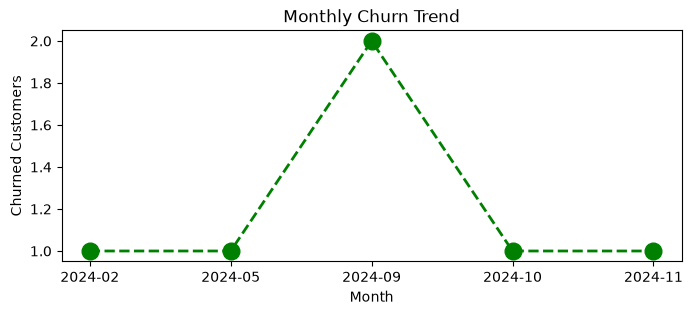

In [68]:

# df_visual['cancellation_date'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] ==1].groupby('cancellation_date').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, marker='o', markersize=12, color='green', linestyle='dashed', linewidth=2)

plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()

### 4.2 Churn by Plan type

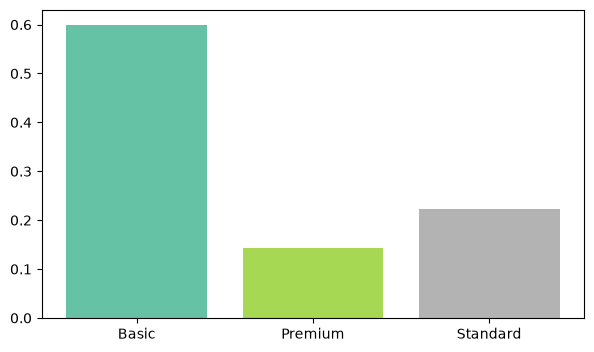

In [69]:

churn_plan = df_visual.groupby("plan_type")['churn_flag'].mean()

# colors = ['grey','purple','blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.show()

### 4.3 Churn by State

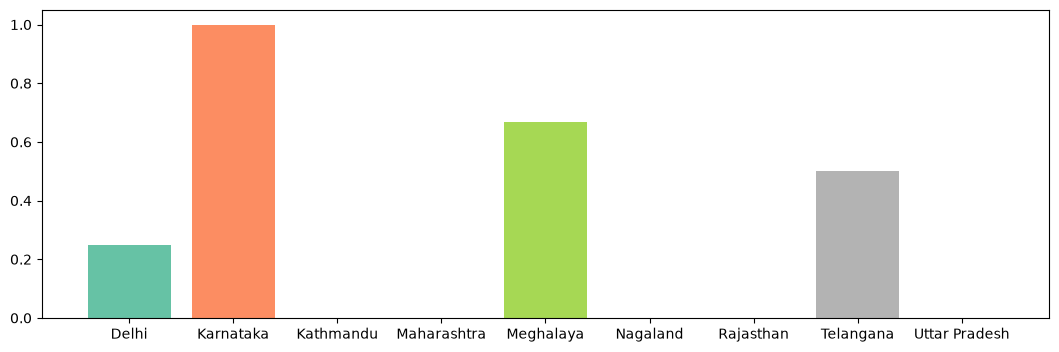

In [70]:

churn_states = df_visual.groupby("state")['churn_flag'].mean()

# colors = ['grey','purple','blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_states)))
plt.figure(figsize=(13,4))
plt.bar(churn_states.index, churn_states.values, color=colors)

plt.show()

# 7. Data visualization using Seaborn

In [71]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

In [72]:
df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'escalations', 'churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [74]:
# Incorrect Method of Encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'churn_risk', 'escalations']].head()

categorical_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [75]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

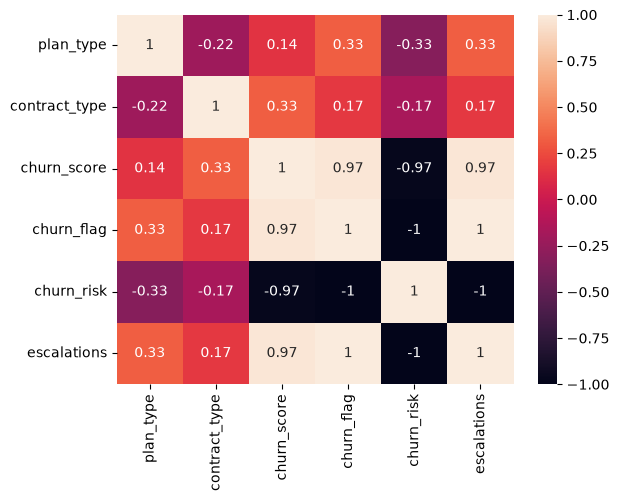

In [76]:
# Heatmap (Correlation Matrix)

sns.heatmap(df_encoded.corr(), annot=True)

# 0 to 1 -> positive correlation
# -1 to 0 -> negative correlation

In [77]:
# Correct Method of Encoding - as numbers based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'churn_risk', 'escalations']].head()

order_mappings = {'plan_type' : ["Basic", "Standard", "Premium"],
    'contract_type': ["Monthly", "Annual"],
    'churn_risk': ['low', 'med', 'high']}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [78]:
df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [79]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

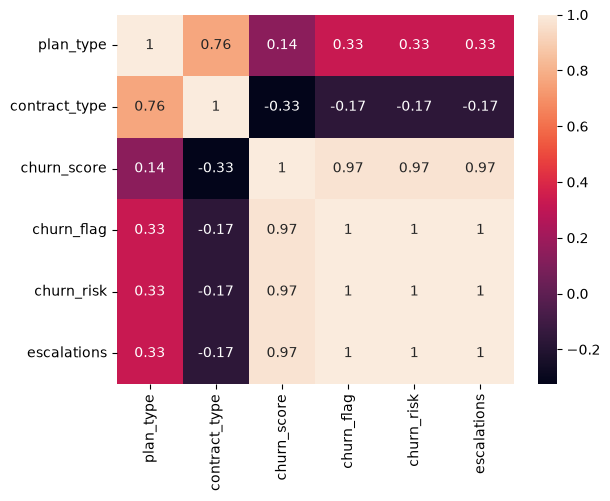

In [80]:
# Heatmap (Correlation Matrix)

sns.heatmap(df_encoded.corr(), annot=True)

# 0 to 1 -> positive correlation
# -1 to 0 -> negative correlation

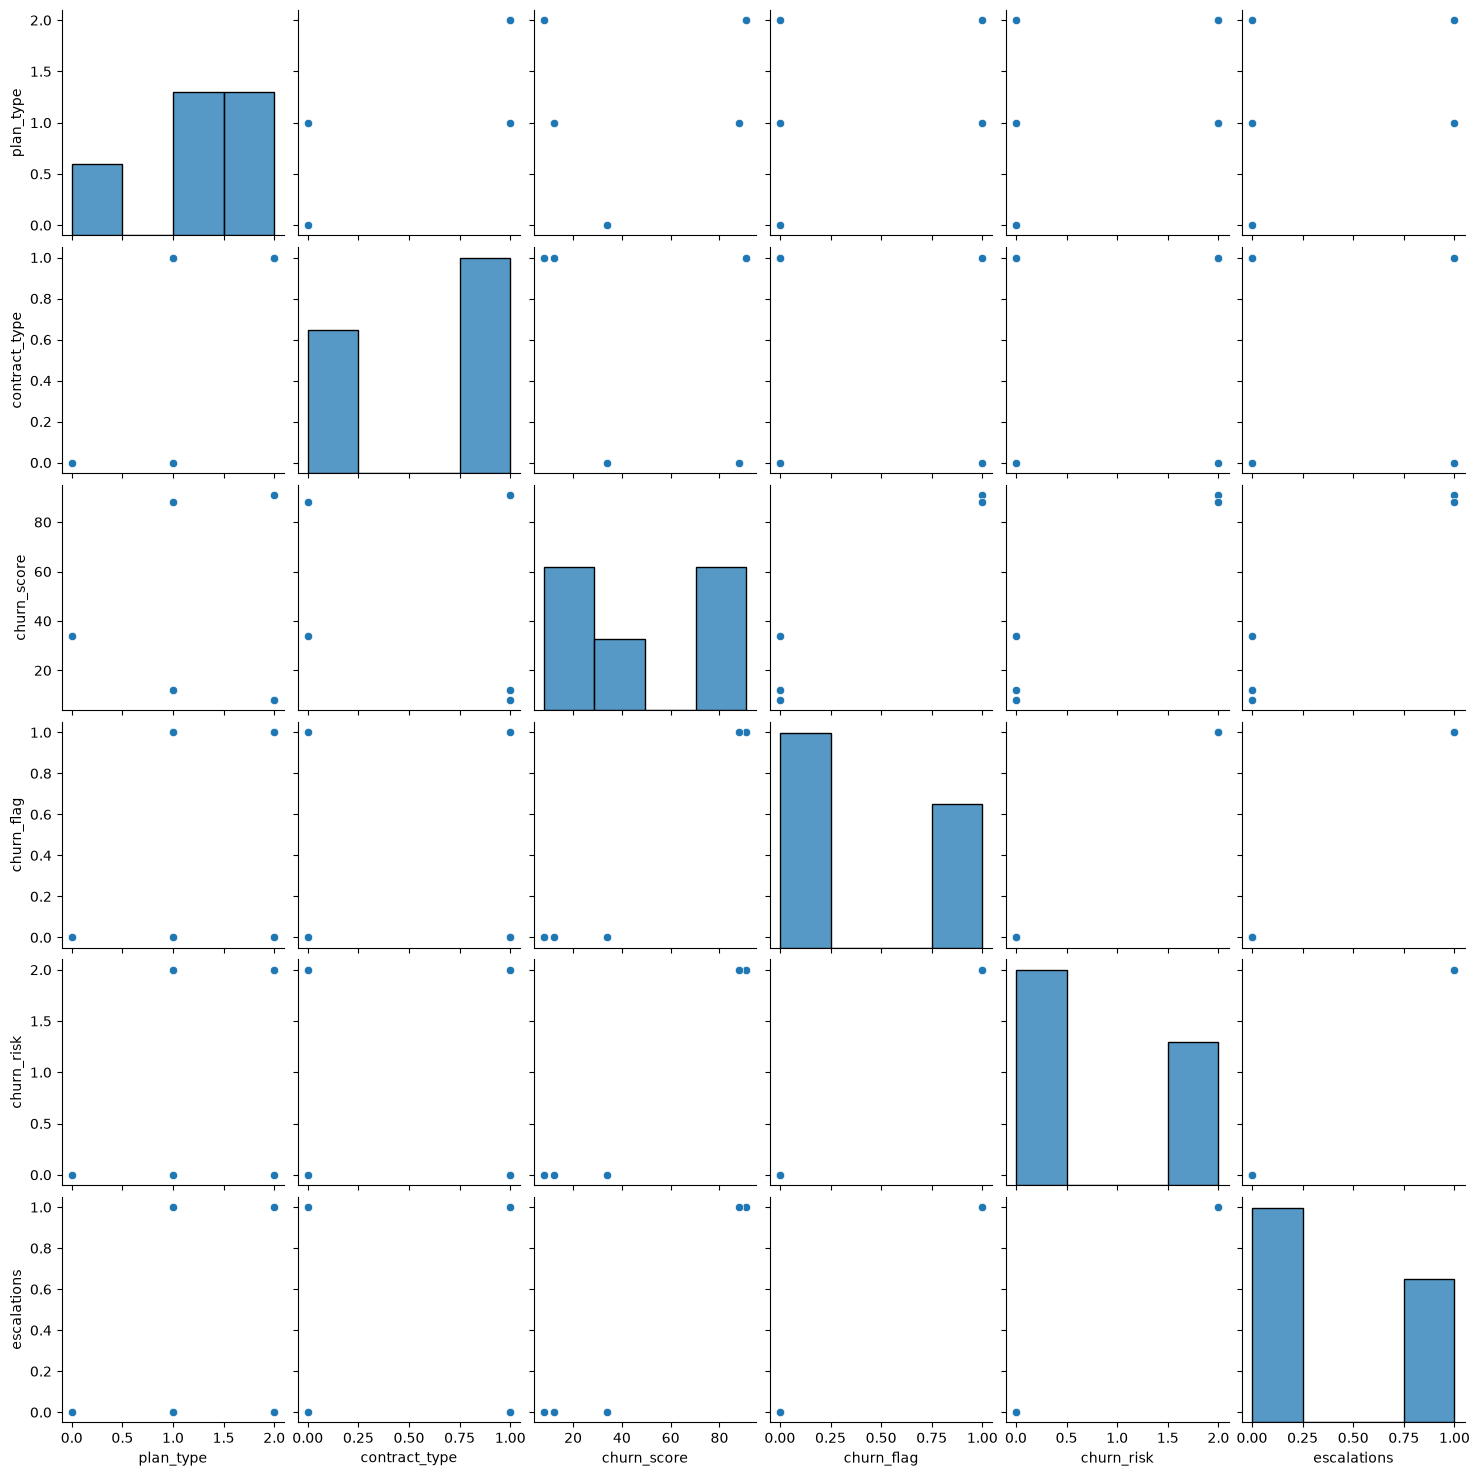

In [81]:
# pairplot - relationship in a dataset
sns.pairplot(df_encoded)

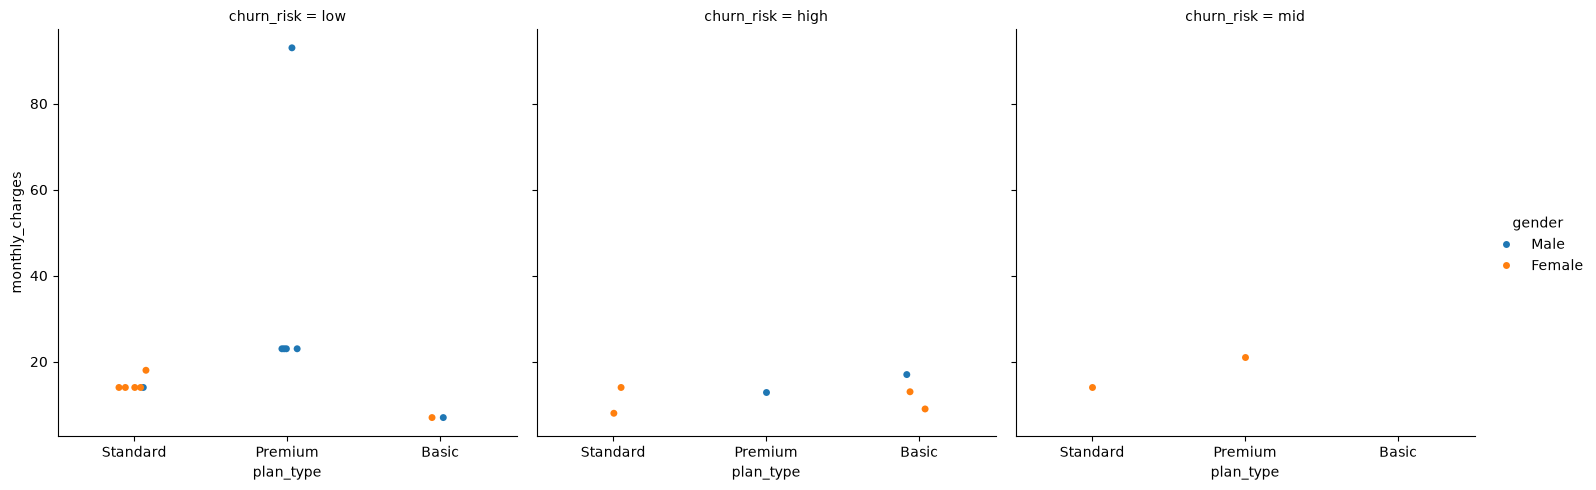

In [82]:
# catplt/Facegrid plot - multi-dimension comparison

sns.catplot(data=df_visual,
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk')

In [83]:
# regression, distribution

In [84]:
pd.pivot_table(
    data= df_visual,
    values= 'churn_flag',
    index= 'plan_type',
    aggfunc= 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [85]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

In [86]:
pd.pivot_table(
    data= df_visual,
    values= ['monthly_charges', 'customerid', 'churn_flag'],
    index= 'plan_type',
    aggfunc= {'monthly_charges': 'sum',
              'customerid' : 'nunique',
              'churn_flag':'mean'
             }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
# Working With SQL in python (pandas)

In [ ]:
# create db in sql
conn = sqlite3.connect('test_database.sqlite')

# table details
conn.execute("create table myusers (first_name text, last_name text, country text, budget integer)")

#commit and save
conn.commit()
print("Database Created Succesfully")

In [ ]:
# insert data

cursor = conn.cursor()

cursor.execute("""
    insert into myusers values 
        ('Jitender', 'Das', 'INDIA', 5000),
        ('Dinker', 'Gupta', 'INDIA', 7000),
        ('Ankit', 'Kumar', 'INDIA' , 50000)
        
    """
)

conn.commit()
print("Data Inserted Succesfully")

In [ ]:
#check inserted data intake
conn = sqlite3.connect('test_database.sqlite')

query = """ select * from myusers"""

df_results = pd.read_sql(query, conn)
df_results.head(10)

In [ ]:
# aggregation
query = """ select last_name, sum(budget) from myusers group by last_name"""
df_agg = pd.read_sql(query, conn)
df_agg

In [ ]:
# always close the connection with db once the task is over
conn.close()